# Практическая работа № 4

**Цель работы:** познакомиться с архитектурой трансформеров и механизмом self-attention, а также изучить применение Transformer-моделей для обработки текстовых данных.

**Задачи:**

1. Построить и обучить модель на основе трансформера.
2. Проанализировать процесс обучения с помощью графиков функции потерь, оценить качество модели с помощью метрик.
3. Провести эксперименты с гиперпараметрами и сравнить результаты,
сделать выводы.

---

**Теоретическая справка**

Трансформеры — это архитектура нейронных сетей, предназначенная для обработки последовательностей данных. В отличие от рекуррентных сетей, трансформеры обрабатывают всю последовательность одновременно, а не поэтапно. Основой архитектуры является механизм self-attention, который позволяет модели определять, какие элементы последовательности наиболее важны при обработке текущего элемента.

**Задача**

Трансформеры широко используются в задачах обработки текста, анализа последовательностей и компьютерного зрения. В данной работе будет рассматриваться архитектура Transformer Encoder для решения задачи классификации текста, а конкретно анализа тональности (определение эмоциональной окраски). Необходимо классифицировать текст как положительный или отрицательный. Это относится к задаче классификации последовательностей, так как входными данными являются текстовые последовательности.

**Архитектура трансформера**

Основным элементом трансформера является механизм self-attention, который позволяет каждому слову учитывать информацию от других слов в предложении. Благодаря этому модель лучше понимает контекст.

Основные компоненты Transformer Encoder:
* Embedding слой — преобразует слова в векторы признаков.
* Positional Encoding — добавляет информацию о порядке слов в последовательности.
* Multi-Head Self-Attention — вычисляет связи между словами.
* Feed Forward Network — выполняет дополнительное нелинейное преобразование признаков.
* Layer Normalization и residual connections — стабилизируют обучение.
* Для классификации используется выходной слой с функцией активации Softmax.

**Функции активации и обучение**

Внутри модели Transformer обычно используется функция активации GELU, которая обеспечивает более плавное преобразование значений по сравнению с ReLU и хорошо подходит для глубоких трансформерных моделей. На выходном слое для задачи классификации используется Softmax, так как необходимо получить вероятности принадлежности текста к каждому классу.

Функция потерь CrossEntropyLoss, стандартная функция для многоклассовой и бинарной классификации. Оптимизатор AdamW — модификация оптимизатора Adam, часто применяемая при обучении трансформеров.

**Выбранная модель**

В работе будет использоваться готовая Transformer-модель BERT (Bidirectional Encoder Representations from Transformers) от Google Research, одна из самых популярных моделей для обработки естественного языка. Модель учитывает контекст слова как слева, так и справа. Для данной задачи будет использоваться предобученная модель BERT с дополнительным классификационным слоем.


---


**Используемые инструменты**

* PyTorch — для построения и обучения нейронных сетей
* Transformers (Hugging Face) — библиотека с готовыми Transformer-моделями
* NumPy — для работы с массивами данных
* Pandas — для обработки датасета
* Matplotlib — для построения графиков обучения

In [1]:
# Используемые библиотеки
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import numpy as np
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

## 1. Загрузка датасета

Для обучения модели был выбран датасет IMDb Large Movie Review Dataset, так как он содержит текстовые данные и широко используется для задач анализа тональности текста: https://www.kaggle.com/datasets/ghnshymsaini/large-movie-review-dataset

Датасет состоит 50 000 размеченных текстовых отзывов пользователей на фильмы с сайта IMDb. Каждый отзыв относится к одному из двух классов: positive — положительный отзыв, negative — отрицательный отзыв. Также присутствуют дополнительные неразмеченные данные, которые могут использоваться для задач без учителя.

Каждый объект представляет собой текстовый отзыв различной длины. В качестве целевой переменной используется тональность текста.

In [2]:
# Распаковка архива
zip_path = 'archive.zip'
extract_path = 'imdb_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

def load_imdb_data(base_path):
    data = []
    # Проходим по папкам train и test
    for split in ['train', 'test']:
        for sentiment in ['pos', 'neg']:
            path = Path(base_path) / 'IMDB Dataset' / split / sentiment

            for file_path in path.glob('*.txt'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    data.append({
                        'text': f.read(),
                        'label': 1 if sentiment == 'pos' else 0,
                        'split': split
                    })
    return pd.DataFrame(data)

df = load_imdb_data(extract_path)

print(f"Всего записей: {len(df)}")
print(df.head())

Всего записей: 50000
                                                text  label  split
0  But this is a great martial arts film. Liu Chi...      1  train
1  I found the storyline in this movie to be very...      1  train
2  Lots of singing and dancing in this one, espec...      1  train
3  Great fun. I went with 8 friends to a sneak pr...      1  train
4  At least something good came out of Damon Runy...      1  train


Проверим, насколько длинные отзывы и нет ли дисбаланса классов.

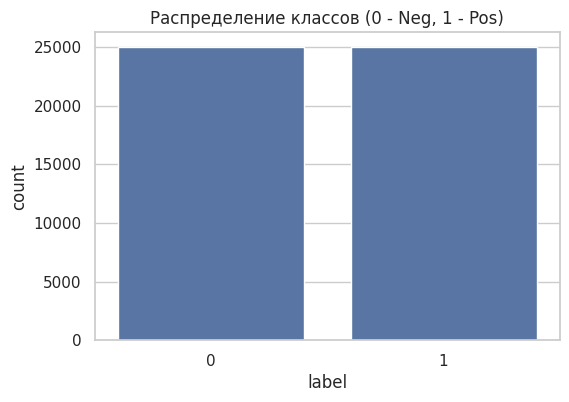

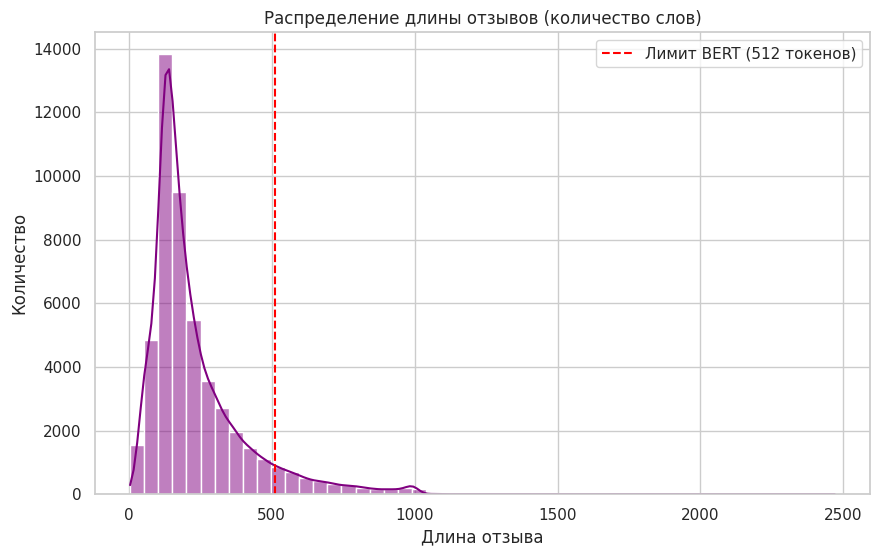

Средняя длина отзыва: 231.16 слов
Медианная длина: 173.0 слов


In [3]:
# Настройка стиля
sns.set(style="whitegrid")

# Проверка баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Распределение классов (0 - Neg, 1 - Pos)')
plt.show()

# Анализ длины текстов
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Распределение длины отзывов (количество слов)')
plt.xlabel('Длина отзыва')
plt.ylabel('Количество')
plt.axvline(x=512, color='red', linestyle='--', label='Лимит BERT (512 токенов)')
plt.legend()
plt.show()

print(f"Средняя длина отзыва: {df['word_count'].mean():.2f} слов")
print(f"Медианная длина: {df['word_count'].median()} слов")

BERT принимает только последовательности до 512 токенов, поэтому часть текстов придется обрезать. Но для ускорения обучения будем брать по 256 токенов, медианная длина 173 слова, поэтому основную часть отзывов 256 токенов покроет.

In [4]:
# Используем стандартный токенизатор для bert-base-uncased
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

# Пример токенизации одного предложения
sample_text = df.iloc[0]['text'][:100]
tokens = tokenizer.tokenize(sample_text)
print(f"Текст: {sample_text}")
print(f"Токены: {tokens}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Текст: But this is a great martial arts film. Liu Chia Liang ranks second to none as a fight choreographer,
Токены: ['but', 'this', 'is', 'a', 'great', 'martial', 'arts', 'film', '.', 'liu', 'chi', '##a', 'liang', 'ranks', 'second', 'to', 'none', 'as', 'a', 'fight', 'choreographer', ',']


Напишем класс, который токенизирует текст. Для скорости возьмем часть данных (2000 для обучения и 500 для теста).

In [5]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создаем DataLoader для обучения и теста
train_df = df[df['split'] == 'train'].sample(2000)
test_df = df[df['split'] == 'test'].sample(500)

MAX_LEN = 256
BATCH_SIZE = 16

train_dataset = IMDBDataset(
    texts=train_df.text.to_numpy(),
    labels=train_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = IMDBDataset(
    texts=test_df.text.to_numpy(),
    labels=test_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## 2. Создание и обучение модели

Возьмем предобученную модель bert-base-uncased. Она уже знает английский язык, остается только дообучить её под специфику киноотзывов.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загружаем готовую модель с классификатором на 2 класса
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
model.to(device)

# Оптимизатор AdamW
optimizer = AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Веса предобученной языковой модели BERT успешно загружены, а финальный классификационный слой был инициализирован случайными значениями (состояние MISSING). Лишние слои предобучения были исключены (состояние UNEXPECTED), так как они не требуются для задачи анализа тональности.

**Обучим модель.** Цикл пройдет по данным, посчитает ошибку и обновит веса. Будем сохранять историю потерь для графика.

Для моделей архитектуры BERT стандартным является обучение в 2–4 эпохи, поэтому зададим 3 эпохи (делаем только fine-tuning под конкретную задачу, а не обучаем с нуля). Также, трансформеры мощные модели с миллионами параметров и если обучать их слишком долго на небольшом датасете, будет переобучение.

В выходном слое BertForSequenceClassification для вычисления потерь неявно используется функция активации Softmax (внутри CrossEntropyLoss). Внутри самой модели используется GELU, которая помогает пропускать градиенты лучше, чем обычный ReLU, за счет плавной кривой.

Метрику качества используем Accuracy. Поскольку в IMDb поровну хороших и плохих отзывов, эта метрика объективно показывает, насколько хорошо модель справляется.

In [7]:
EPOCHS = 3
history = {'train_loss': [], 'train_acc': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct_predictions = 0

    print(f"Эпоха {epoch + 1}/{EPOCHS}")

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Вычисляем точность
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)

        total_loss += loss.item()

        # Обратный проход
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    avg_acc = correct_predictions.double() / len(train_df)

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(avg_acc.item())

    print(f"Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.4f}")

Эпоха 1/3
Loss: 0.4345 | Accuracy: 0.7875
Эпоха 2/3
Loss: 0.1716 | Accuracy: 0.9390
Эпоха 3/3
Loss: 0.0832 | Accuracy: 0.9740


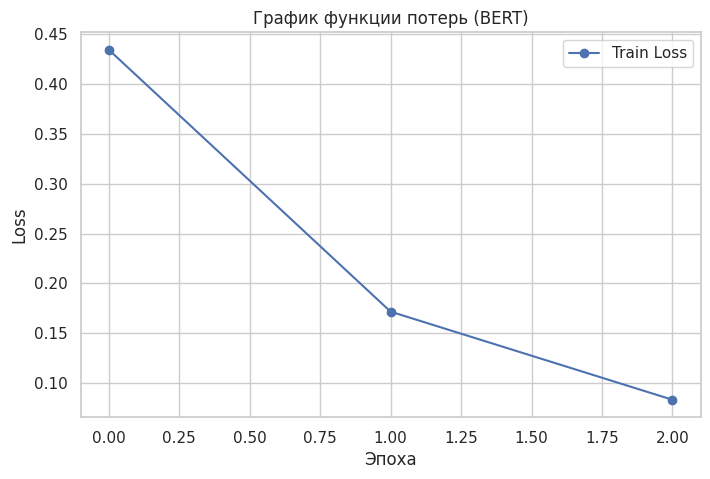

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], marker='o', label='Train Loss')
plt.title('График функции потерь (BERT)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

В обучении базовой модели BERT видна высокая скорость сходимости: за 3 эпохи функция потерь снизилась с 0.43 до 0.083, а точность выросла с 78.75% до 97.4%. Высокий результат объясняется тем, что предобученная модель уже обладает глубокими знаниями о языке и требует лишь небольшой настройки под конкретную задачу. Процесс обучения без признаков переобучения, что подтверждает корректность выбора оптимизатора и скорости обучения. Финальный показатель точности доказывает высокую эффективность трансформерных архитектур в задачах анализа тональности текста.

## 3. Эксперименты с параметрами

Заменим современный AdamW на классический SGD и увеличим скорость обучения. Посмотрим, насколько BERT чувствителен к выбору алгоритма оптимизации.

In [10]:
model_exp1 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# Меняем оптимизатор на SGD и увеличиваем lr до 1e-3
optimizer_exp1 = torch.optim.SGD(model_exp1.parameters(), lr=1e-3)
history_exp1 = {'train_loss': [], 'train_acc': []}

for epoch in range(EPOCHS):
    model_exp1.train()
    total_loss, correct_preds = 0, 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_exp1.zero_grad()
        outputs = model_exp1(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_exp1.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs.logits, dim=1)
        correct_preds += torch.sum(preds == labels)

    avg_loss = total_loss / len(train_loader)
    avg_acc = correct_preds.double() / len(train_loader.dataset)
    history_exp1['train_loss'].append(avg_loss)
    history_exp1['train_acc'].append(avg_acc.item())
    print(f"Эпоха {epoch+1}: Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Эпоха 1: Loss: 0.6665, Accuracy: 0.6060
Эпоха 2: Loss: 0.5279, Accuracy: 0.7500
Эпоха 3: Loss: 0.3836, Accuracy: 0.8360


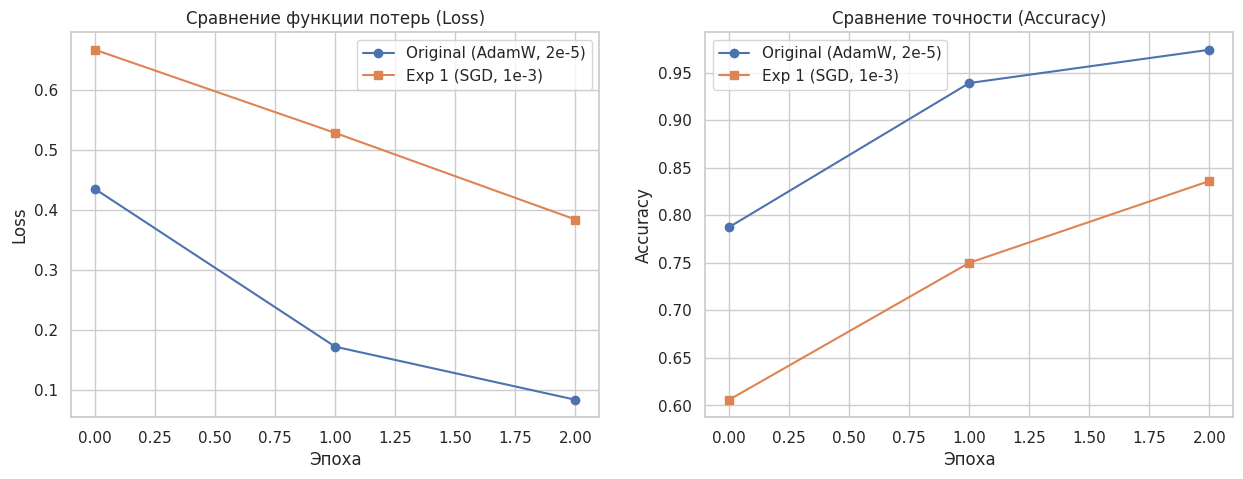

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График Loss
ax1.plot(history['train_loss'], label='Original (AdamW, 2e-5)', marker='o')
ax1.plot(history_exp1['train_loss'], label='Exp 1 (SGD, 1e-3)', marker='s')
ax1.set_title('Сравнение функции потерь (Loss)')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# График Accuracy
ax2.plot(history['train_acc'], label='Original (AdamW, 2e-5)', marker='o')
ax2.plot(history_exp1['train_acc'], label='Exp 1 (SGD, 1e-3)', marker='s')
ax2.set_title('Сравнение точности (Accuracy)')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

Переход от оптимизатора AdamW к классическому методу стохастического градиентного спуска SGD с увеличенным в 50 раз шагом обучения показывает значительную деградацию качества обучения по сравнению с базовой моделью. Accuracy снизилась с 97.4% до 83.6%, loss у SGD в несколько раз выше (0.3836 и 0.0832 у оригинала). На графиках видно, что кривая SGD гораздо медленнее сходится к оптимуму. Оригинальная модель уже на первой эпохе достигла точности 78.7%, а модели с SGD потребовалось три эпохи, чтобы достичь сопоставимого результата.

Такая разница в качестве объясняется архитектурными особенностями BERT. SGD обновляет все веса с фиксированным шагом, что при работе с глубокими сетями часто приводит к застреванию в локальных минимумах. AdamW использует адаптивную оценку моментов, подбирая индивидуальный шаг обучения для каждого параметра.

Теперь упростим модель, уменьшив количество слоев. Чтобы это сделать, проще всего использовать DistilBERT. Это облегченная версия BERT, где слоев в 2 раза меньше (6 вместо 12).

In [12]:
# Загружаем облегченную модель
distil_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_distil = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
optimizer_distil = AdamW(model_distil.parameters(), lr=2e-5)

# Нужно пересоздать DataLoader, так как у DistilBERT свои токены
distil_train_dataset = IMDBDataset(
    train_loader.dataset.texts,
    train_loader.dataset.labels,
    distil_tokenizer,
    MAX_LEN
)
distil_train_loader = DataLoader(distil_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

history_distil = {'train_loss': [], 'train_acc': []}

for epoch in range(EPOCHS):
    model_distil.train()
    total_loss, correct_preds = 0, 0
    for batch in distil_train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_distil.zero_grad()
        outputs = model_distil(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_distil.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs.logits, dim=1)
        correct_preds += torch.sum(preds == labels)

    avg_loss = total_loss / len(distil_train_loader)
    avg_acc = correct_preds.double() / len(train_loader.dataset)
    history_distil['train_loss'].append(avg_loss)
    history_distil['train_acc'].append(avg_acc.item())
    print(f"Эпоха {epoch+1}: Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Эпоха 1: Loss: 0.4570, Accuracy: 0.7845
Эпоха 2: Loss: 0.2216, Accuracy: 0.9235
Эпоха 3: Loss: 0.1086, Accuracy: 0.9655


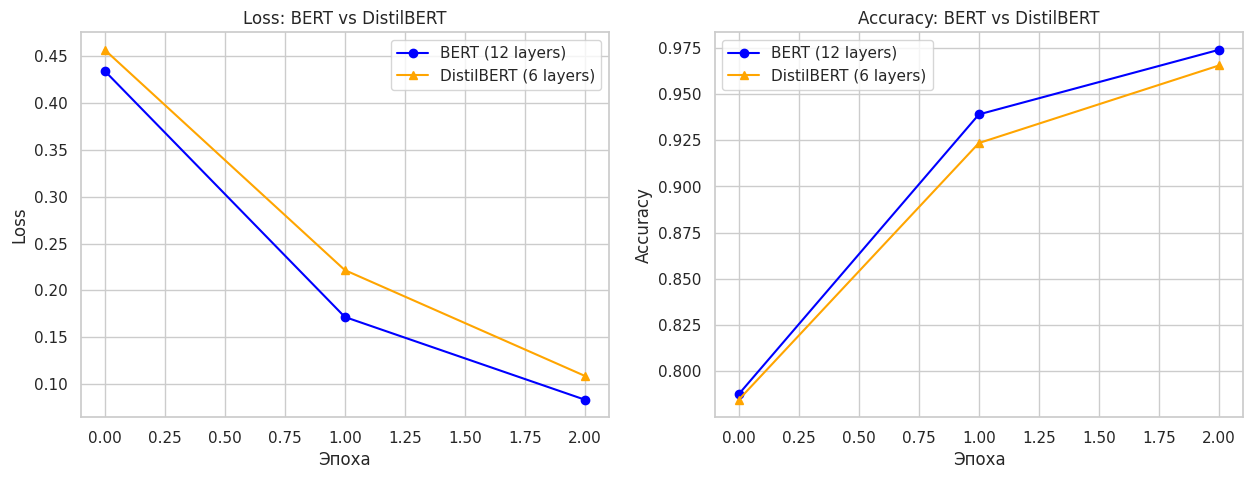

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График Loss
ax1.plot(history['train_loss'], label='BERT (12 layers)', color='blue', marker='o')
ax1.plot(history_distil['train_loss'], label='DistilBERT (6 layers)', color='orange', marker='^')
ax1.set_title('Loss: BERT vs DistilBERT')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# График Accuracy
ax2.plot(history['train_acc'], label='BERT (12 layers)', color='blue', marker='o')
ax2.plot(history_distil['train_acc'], label='DistilBERT (6 layers)', color='orange', marker='^')
ax2.set_title('Accuracy: BERT vs DistilBERT')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

Стандартная модель BERT (12 слоев) заменена на DistilBERT (6 слоев). Графики показывают, что облегченная модель справляется с задачей классификации почти так же эффективно, как и оригинал. Итоговая точность составила 96.55%, разница с полным BERT меньше процента. Динамика снижения ошибки тоже практически идентична базовой модели, финальное значение 0.1086. При незначительной потере качества процесс обучения и обработки данных стал значительно быстрее благодаря сокращению количества параметров.

Эксперимент показывает избыточность 12 слоев BERT для данной задачи анализа тональности. Механизмы внимания даже в 6 слоях успешно выделяют ключевые маркеры, определяющие эмоциональный окрас отзыва.

## Вывод

В рамках работы была реализована и исследована система автоматического анализа тональности текста на базе архитектуры Transformer (модель BERT). На основе проведенных экспериментов и анализа полученных метрик можно сделать следующие выводы:

1. Использование предобученной модели BERT-base-uncased позволило достичь высокой точности классификации всего за 3 эпохи обучения. Это доказывает преимущество подхода Fine-tuning: вместо обучения с нуля, модель использует уже имеющиеся знания о языке, накопленные в процессе предобучения на гигантских корпусах текста.
2. Сравнение базовой модели с использующей SGD показало важность выбора оптимизатора для глубоких сетей. Адаптивные методы, такие как AdamW, превосходят классический градиентный спуск в подобных задачах.
3. Эксперимент с DistilBERT продемонстрировал возможности оптимизации архитектуры. Уменьшение количества слоев в два раза привело к незначительному снижению точности. При этом модель стала значительно легче и быстрее, что делает её более предпочтительной.

Результаты подтверждают, что модели семейства BERT эффективны для задач NLP. Для достижения максимального результата необходимо не только использовать мощные архитектуры, но и правильно подбирать гиперпараметры обучения под конкретную задачу.